In [1]:
!pip install maldideepkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.5 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# MaldiDeepKit Analysis of the Duroux *S. aureus* AMR Dataset

This notebook demonstrates a **complete antimicrobial resistance (AMR) classification pipeline**
using the [MaldiDeepKit](https://github.com/EttoreRocchi/MaldiDeepKit) framework on
the DRIAMS **Duroux** dataset (*Staphylococcus aureus*, 2018 cohort).

---
## Dataset Overview

| Property | Value |
|---|---|
| Species | *Staphylococcus aureus* (primary) + 362 others |
| Samples | 14,112 binned MALDI-TOF spectra |
| Bins per spectrum | 6,000 (2000–20000 Da, 3 Da bin-width) |
| Drugs tested | 64 antibiotics / antifungals |
| Labels | 0 = Resistant (R), 1 = Susceptible (S) |
| Predefined splits | train (7,720) / test (5,432) / val (960) |
| Precomputed embeddings | 512-dim masked autoencoder (provided) |

---
## What this notebook covers

1. **Data loading & EDA** — inspect spectra, class balance, missing patterns
2. **Single‑drug classification** — train four architectures on Ciprofloxacin
3. **Multi‑drug classification** — loop over top drugs, record metrics
4. **Model comparison** — MLP vs CNN vs ResNet vs Transformer
5. **Cross‑validation** — stratified, leak‑safe 5‑fold CV
6. **Attention interpretation** — visualise which m/z bins the MLP gates on
7. **Uncertainty quantification** — MC Dropout + conformal prediction
8. **Ensemble** — average‑of‑probabilities ensemble

In [3]:
# =============================================================================
# 1. IMPORTS & CONFIGURATION
# =============================================================================

# --- Standard library ---
import os                # filesystem paths for saved models
import sys               # access Python version / path info
import warnings          # suppress FutureWarning/UserWarning noise
import json              # read/write model hyperparameter .json files
from pathlib import Path # cross-platform path handling (DATA_DIR, OUT_DIR)

# --- Numerical & data manipulation ---
import numpy as np       # matrix operations, .npy loading, float32 arrays
import pandas as pd      # CSV metadata loading, pivot tables, DataFrames

# --- Plotting ---
import matplotlib.pyplot as plt  # spectra plots, confusion matrices, ROC curves
import matplotlib.ticker as ticker  # custom axis tick formatting (unused here)
import seaborn as sns            # (optional) nicer default plot styling

# --- Deep learning framework ---
import torch             # PyTorch backend used by all MaldiDeepKit models

# --- MaldiDeepKit: four sklearn-compatible classifier architectures ---
import maldideepkit      # package metadata (version, etc.)
from maldideepkit import (
    MaldiMLPClassifier,          # MLP with optional sigmoid-gated attention
    MaldiCNNClassifier,          # 1-D ConvNet: Conv1D + BatchNorm + MaxPool
    MaldiResNetClassifier,       # 1-D ResNet-18: residual blocks + skip connections
    MaldiTransformerClassifier,  # 1-D ViT: patch embedding + self-attention
)

# --- MaldiDeepKit: uncertainty quantification ---
from maldideepkit.uncertainty import MCDropoutEstimator, ConformalPredictor
# MCDropoutEstimator   - Monte Carlo Dropout: runs N stochastic forward passes,
#                        decomposes uncertainty into epistemic + aleatoric
# ConformalPredictor   - split conformal prediction with LAC score,
#                        guaranteed marginal coverage (e.g. 90 %)

# --- MaldiDeepKit: ensemble ---
from maldideepkit.utils import SpectralEnsemble
# SpectralEnsemble  - mean-of-probabilities ensemble of multiple classifiers

# --- Scikit-learn: data splitting & cross-validation ---
from sklearn.model_selection import (
    train_test_split,     # random train/test split (used for conformal calibration split)
    StratifiedKFold,      # stratified K-fold CV, preserves class ratios per fold
    cross_val_score,      # shorthand for cross-validated scoring (single metric)
)

# --- Scikit-learn: classification metrics & visualisation ---
from sklearn.metrics import (
    accuracy_score,              # fraction of correct predictions
    balanced_accuracy_score,     # mean of per-class recall (handles imbalance)
    f1_score,                    # harmonic mean of precision & recall (macro avg)
    roc_auc_score,               # area under ROC curve (threshold-independent)
    classification_report,       # per-class precision/recall/F1 summary table
    confusion_matrix,            # raw TP/FP/TN/FN counts
    ConfusionMatrixDisplay,      # visual confusion matrix plot
    RocCurveDisplay,             # visual ROC curve plot
)

# Suppress excessive warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


---
## 2. LOAD & INSPECT THE DATA

In [4]:
from pathlib import Path

# --- Configuration for data paths and random seed ---
# IMPORTANT: Update these paths to where your data is located.
# The `MaldiDeepKit_data` folder should be downloaded from the original
# repository and placed in your Google Drive, or adjust paths accordingly.
DATA_DIR = Path("/content/drive/MyDrive/Flower/Duroux_D_dirams/A2018/A2018")
SPECTRA_PATH = DATA_DIR / "rawSpectra_data.npy"
# SPLITS_PATH = DATA_DIR / "data_splits.csv" # Not directly used in this cell, but needed later
# LONG_TABLE_PATH = DATA_DIR / "combined_long_table.csv" # Not directly used in this cell, but needed later
# EMBEDDINGS_PATH = DATA_DIR / "embeddings.npy" # Not directly used in this cell, but needed later

OUT_DIR = Path("/content/drive/MyDrive/Flower/Duroux_D_dirams/0-Analysis/0-0-1-duroux_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True) # Ensure output directory exists

SEED = 42 # Random seed for reproducibility

# -----------------------------------------------------------------------------
# 2.1  Load the binned spectra matrix
# -----------------------------------------------------------------------------
# The .npy file is a (14112, 6000) float64 matrix.
# Row *i* corresponds to sample metadata row *i*.  MaldiDeepKit expects float32,
# so we cast on load.

X_full = np.load(SPECTRA_PATH).astype("float32")
n_samples, n_bins = X_full.shape
print(f"Spectra: {X_full.shape}  |  dtype: {X_full.dtype}")
print(f"Intensity range: [{X_full.min():.4f}, {X_full.max():.4f}]")

Spectra: (14112, 6000)  |  dtype: float32
Intensity range: [0.0000, 0.0627]


In [5]:
# -----------------------------------------------------------------------------
# 2.2  Load metadata tables
# -----------------------------------------------------------------------------
# Definiamo i percorsi mancanti basandoci sulla DATA_DIR configurata in precedenza
SPLITS_PATH = DATA_DIR / "data_splits.csv"
LONG_TABLE_PATH = DATA_DIR / "combined_long_table.csv"

# Caricamento dei file CSV
splits_df = pd.read_csv(SPLITS_PATH)
long_df = pd.read_csv(LONG_TABLE_PATH)

print(f"Splits:      {splits_df.shape}")
print(f"Long table:  {long_df.shape}")
print()
print("Split distribution:")
print(splits_df["Set"].value_counts())
print()
print(f"Unique species: {long_df['species'].nunique()}")
print(f"Unique drugs:   {long_df['drug'].nunique()}")

Splits:      (14112, 2)
Long table:  (174299, 5)

Split distribution:
Set
train         7720
test          5432
validation     960
Name: count, dtype: int64

Unique species: 363
Unique drugs:   64


In [6]:
# -----------------------------------------------------------------------------
# 2.3  Pivot the long table into a sample × drug matrix
# -----------------------------------------------------------------------------
# pivot_table() will insert NaN where a given drug was not tested on a sample.
# The result is a (14112, 64) DataFrame indexed by sample_id.

pivot_df = long_df.pivot_table(
    index="sample_id", columns="drug", values="response"
)
# Re‑index to match the order in data_splits.csv (→ row order of the .npy)
pivot_df = pivot_df.reindex(splits_df["sample_id"])
print(f"Pivot shape (rows × drugs): {pivot_df.shape}")
print(f"\nTop 10 drugs by tested samples:")
print(pivot_df.notna().sum().sort_values(ascending=False).head(10))

Pivot shape (rows × drugs): (14112, 64)

Top 10 drugs by tested samples:
drug
Ciprofloxacin    11539
Imipenem         10869
Cefepime         10572
Meropenem        10052
Ceftriaxone       9663
Cotrimoxazole     9238
Levofloxacin      7069
Ceftazidime       6823
Amikacin          6186
Colistin          6062
dtype: int64


In [7]:
# -----------------------------------------------------------------------------
# 2.4  Load precomputed masked‑autoencoder embeddings (optional)
# -----------------------------------------------------------------------------
# Definizione del percorso per gli embeddings
EMBEDDINGS_PATH = DATA_DIR / "maskedAE_copy10_batch50_embSize512_epoch100_MR25_data.npy"

# Shape: (14112, 512).  These can be used as an alternative feature set for
# shallower classifiers (e.g. linear probe / logistic regression) or as a
# sanity check that the raw spectra contain recoverable signal.

X_emb = np.load(EMBEDDINGS_PATH).astype("float32")
print(f"Embeddings: {X_emb.shape}")

Embeddings: (14112, 512)


---
## 3. EXPLORATORY DATA ANALYSIS

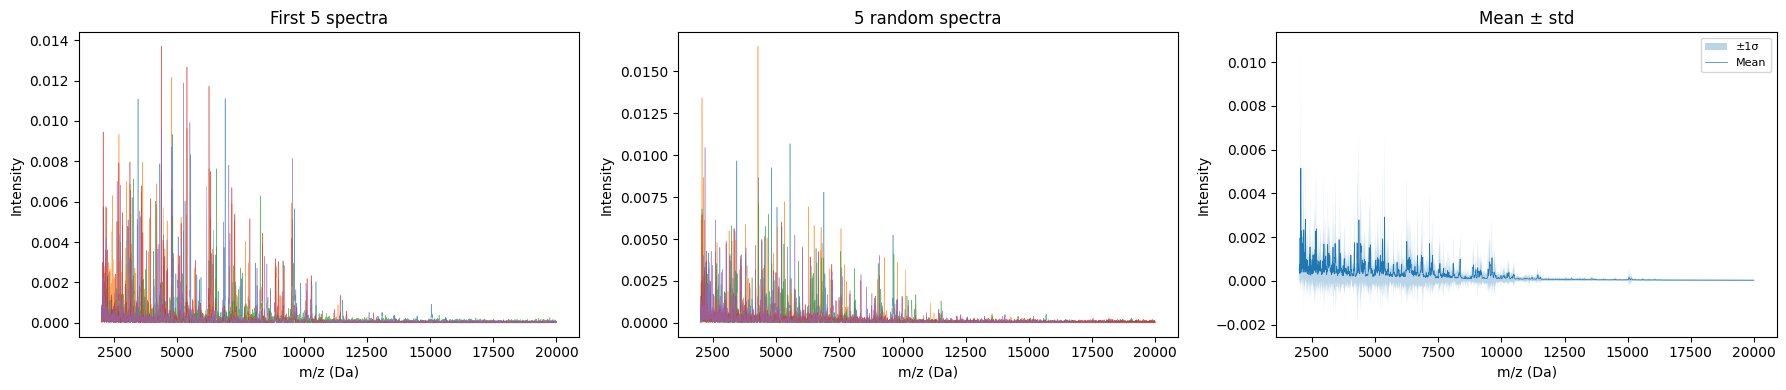

In [8]:
# -----------------------------------------------------------------------------
# 3.1  Visualise a few raw (binned) spectra
# -----------------------------------------------------------------------------
# Each spectrum is a 6000‑element intensity vector covering 2000–20000 Da at
# 3 Da resolution.  We overlay a handful of spectra to show variability.

mz_axis = np.arange(2000, 2000 + n_bins * 3, 3)   # m/z values

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, title, idx in zip(axes, ["First 5 spectra", "5 random spectra", "Mean ± std"],
                           [range(5), np.random.RandomState(1).choice(n_samples, 5, replace=False), None]):
    if idx is not None:
        for i in idx:
            ax.plot(mz_axis, X_full[i], alpha=0.7, lw=0.4)
    else:
        mu = X_full.mean(axis=0)
        sd = X_full.std(axis=0)
        ax.fill_between(mz_axis, mu - sd, mu + sd, alpha=0.3, label="±1σ")
        ax.plot(mz_axis, mu, lw=0.5, label="Mean")
        ax.legend(fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("m/z (Da)")
    ax.set_ylabel("Intensity")
plt.tight_layout()
plt.savefig(OUT_DIR / "spectra_sample.pdf", bbox_inches="tight")
plt.show()

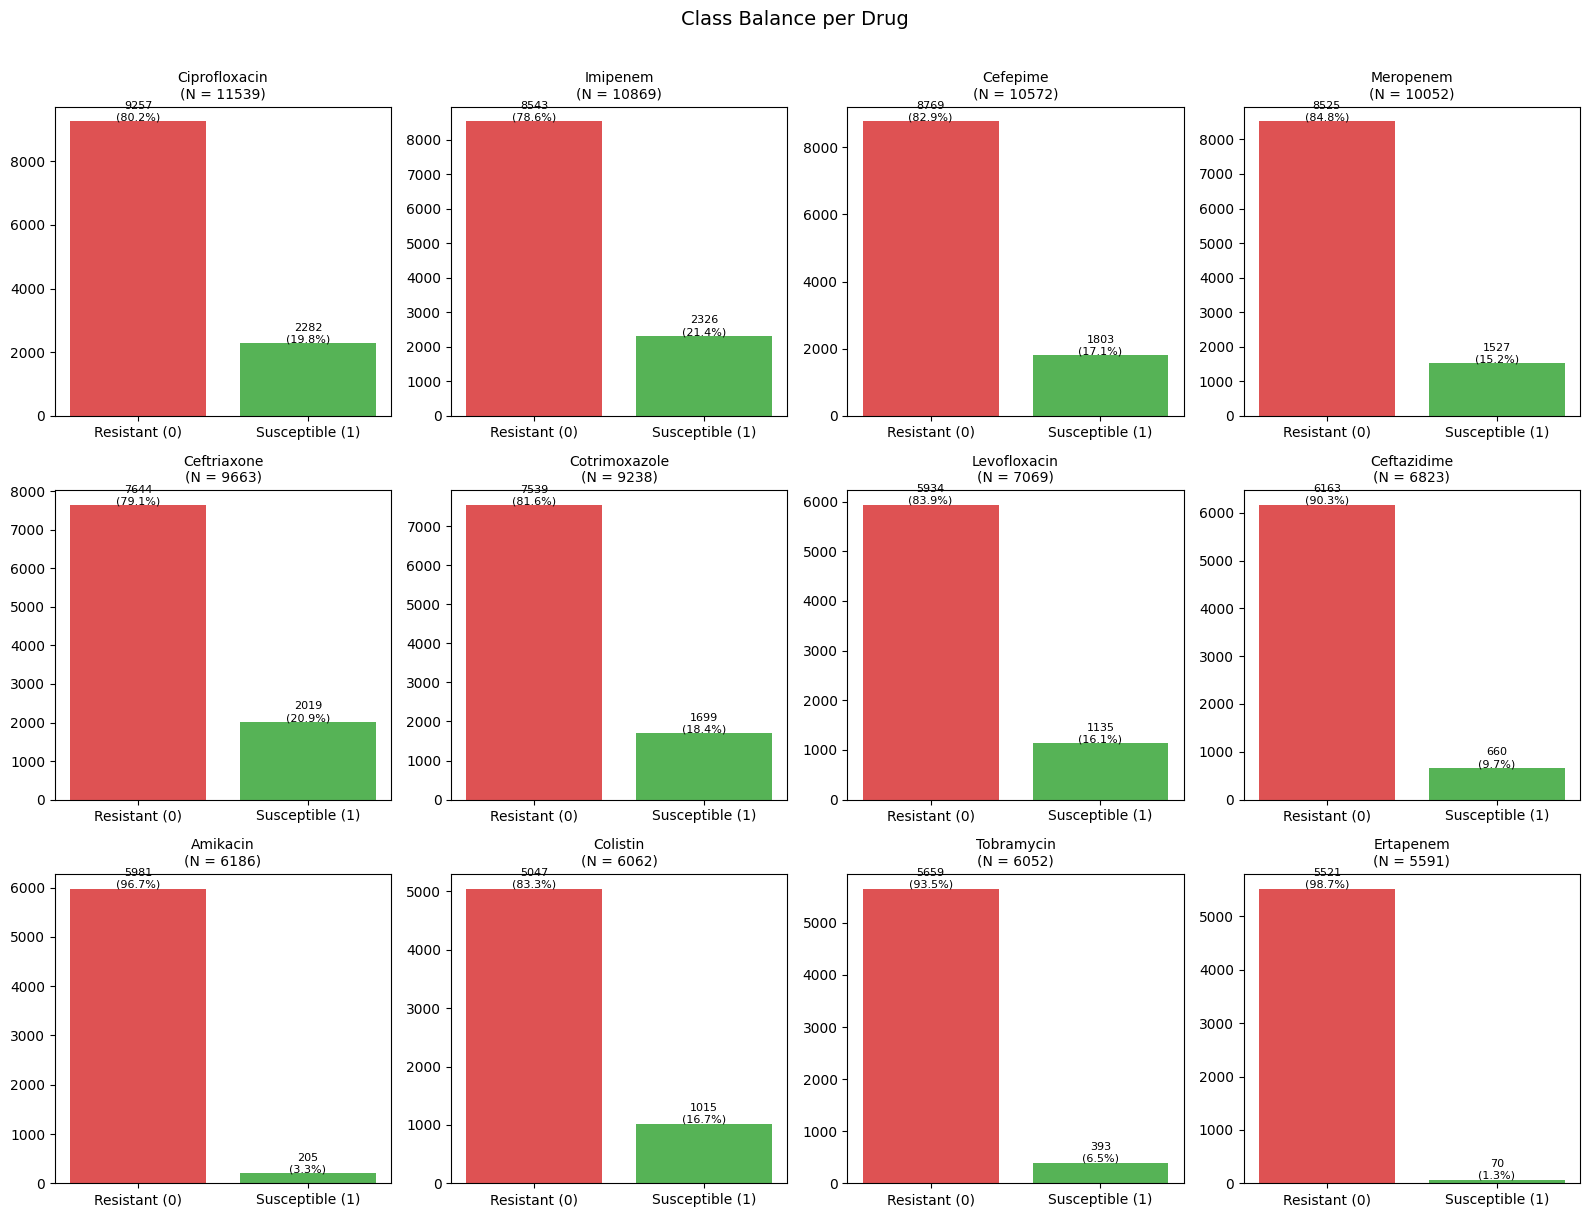

In [9]:
# -----------------------------------------------------------------------------
# 3.2  Class‑balance dashboard for the top drugs
# -----------------------------------------------------------------------------
# Labels are highly imbalanced (75–85 % Resistant for most drugs).
# We use balanced accuracy and F1 to fairly evaluate models.

top_drugs = pivot_df.notna().sum().sort_values(ascending=False).head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, drug in zip(axes.flat, top_drugs):
    counts = pivot_df[drug].value_counts().sort_index()
    labels = ["Resistant (0)", "Susceptible (1)"]
    ax.bar(labels, [counts.get(0, 0), counts.get(1, 0)],
           color=["#d62728", "#2ca02c"], alpha=0.8)
    total = counts.sum()
    ax.set_title(f"{drug}\n(N = {total})", fontsize=10)
    for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        ax.text(i, v + 20, f"{v}\n({v/total*100:.1f}%)", ha="center", fontsize=8)
fig.suptitle("Class Balance per Drug", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "class_balance.pdf", bbox_inches="tight")
plt.show()

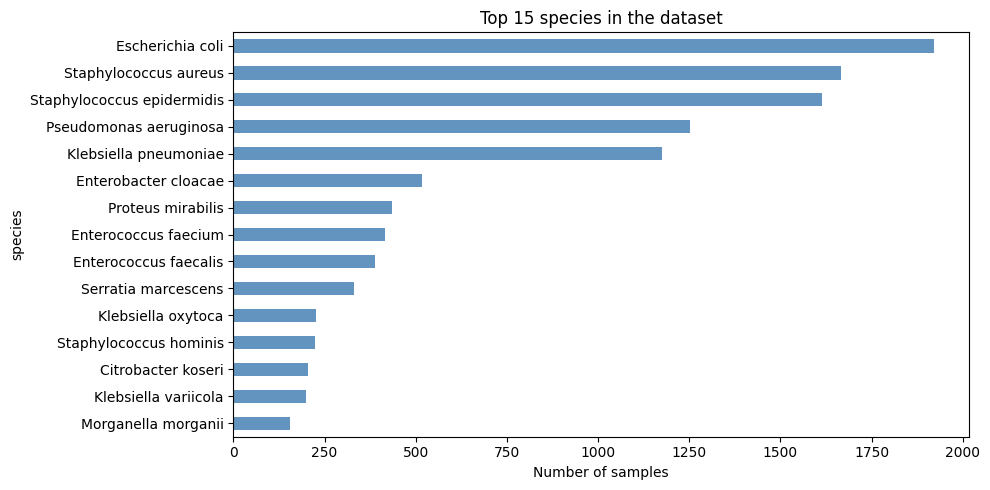

In [10]:
# -----------------------------------------------------------------------------
# 3.3  Species composition
# -----------------------------------------------------------------------------
# Most samples are S. aureus, but 362 other species are also present.

species_cts = long_df.groupby("sample_id")["species"].first()
species_cts = species_cts.reindex(splits_df["sample_id"])
top_species = species_cts.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_species.plot(kind="barh", ax=ax, color="steelblue", alpha=0.85)
ax.set_xlabel("Number of samples")
ax.set_title("Top 15 species in the dataset")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "species_distribution.pdf", bbox_inches="tight")
plt.show()

---
## 4. SINGLE‑DRUG CLASSIFICATION — *Ciprofloxacin*

We start with the most‑tested drug to establish baselines.  The pipeline is:

1. Extract labels for the drug, dropping NaN (untested samples).
2. Apply the author‑provided train / test / validation split.
3. Fit each of the four MaldiDeepKit architectures.
4. Compare metrics on the held‑out test set.

In [11]:
# -----------------------------------------------------------------------------
# 4.1  Helper: prepare a drug‑specific dataset
# -----------------------------------------------------------------------------

def prepare_drug_data(drug_name, use_test_val=False):
    """Extract X, y and split masks for a given drug.

    Parameters
    ----------
    drug_name : str
        Name of the drug column in pivot_df.
    use_test_val : bool
        If True, combine the author‑defined 'test' and 'validation' splits into
        a single hold‑out set.  If False, keep the three‑way split.

    Returns
    -------
    X : ndarray (N, 6000)
    y : ndarray (N,)
    masks : dict with bool arrays for 'train', 'test', 'valid'
    """
    # Drop samples not tested against this drug
    valid_mask = pivot_df[drug_name].notna().to_numpy()
    X = X_full[valid_mask]
    y = pivot_df[drug_name].dropna().to_numpy(dtype=np.int64)
    split_subset = splits_df.loc[valid_mask, "Set"].to_numpy()

    masks = {
        "train": (split_subset == "train"),
        "test": (split_subset == "test"),
        "valid": (split_subset == "validation"),
    }

    if use_test_val:
        masks["test"] = masks["test"] | masks["valid"]
        del masks["valid"]

    return X, y, masks


# Extract Ciprofloxacin subset
DRUG = "Ciprofloxacin"
X_cip, y_cip, masks_cip = prepare_drug_data(DRUG, use_test_val=False)

print(f"Drug: {DRUG}")
for key, m in masks_cip.items():
    print(f"  {key:8s}  samples = {m.sum():5d}  |  R = {(y_cip[m]==0).sum():5d}  S = {(y_cip[m]==1).sum():5d}")
print(f"  {'total':8s}  samples = {len(y_cip):5d}  |  R = {(y_cip==0).sum():5d}  S = {(y_cip==1).sum():5d}")

Drug: Ciprofloxacin
  train     samples =  6309  |  R =  5071  S =  1238
  test      samples =  4449  |  R =  3558  S =   891
  valid     samples =   781  |  R =   628  S =   153
  total     samples = 11539  |  R =  9257  S =  2282


In [13]:
# -----------------------------------------------------------------------------
# 4.2  Quick baselines with the precomputed embeddings
# -----------------------------------------------------------------------------
# Before training deep models, we run logistic regression on the 512‑dim
# masked‑autoencoder features.  This confirms the embeddings carry useful
# AMR signal and provides a sanity‑check baseline.

from sklearn.linear_model import LogisticRegression

X_emb_cip = X_emb[pivot_df[DRUG].notna().to_numpy()]

lr = LogisticRegression(max_iter=2000, random_state=SEED)
lr.fit(X_emb_cip[masks_cip["train"]], y_cip[masks_cip["train"]])

for split_name in ["train", "test", "valid"]:
    idx = masks_cip[split_name]
    score = lr.score(X_emb_cip[idx], y_cip[idx])
    bal = balanced_accuracy_score(y_cip[idx], lr.predict(X_emb_cip[idx]))
    print(f"LR‑on‑embeddings  {split_name:7s}  Acc = {score:.4f}  BalAcc = {bal:.4f}")

LR‑on‑embeddings  train    Acc = 0.8607  BalAcc = 0.7128
LR‑on‑embeddings  test     Acc = 0.8076  BalAcc = 0.6168
LR‑on‑embeddings  valid    Acc = 0.8361  BalAcc = 0.6460


In [15]:
# -----------------------------------------------------------------------------
# 4.3  Train the MLP with attention gates (MaldiMLPClassifier)
# -----------------------------------------------------------------------------
# Defaults: log1p input transform, sigmoid‑gated attention on input bins,
# 4‑layer MLP with hidden_dim=512, AdamW, 100 epochs, cosine annealing.
#
# Note: we pass the full X and y and let the classifier split internally
#       via *validation_fraction*.  The author‑provided test set is reserved
#       for final evaluation only.

X_train_mlp = X_cip[masks_cip["train"]]
y_train_mlp = y_cip[masks_cip["train"]]
X_test_mlp = X_cip[masks_cip["test"]]
y_test_mlp = y_cip[masks_cip["test"]]

mlp_cip = MaldiMLPClassifier(
    input_transform="log1p+standardize",  # log1p first, then standardise
    hidden_dim=512,
    use_attention=True,                    # sigmoid-gated per‑bin attention
    epochs=50,
    batch_size=64,
    learning_rate=0.5e-4,
    weight_decay=1e-3,        # ← L2 regularization
    warmup_epochs=10,           # ← gradual LR ramp-up
    dropout_high=0.4,          # ← was 0.3, raise to 0.4
    random_state=SEED,
    verbose=True,
)

print("Fitting MaldiMLPClassifier on Ciprofloxacin ...")
mlp_cip.fit(X_train_mlp, y_train_mlp)

# Evaluate on the held‑out test split
mlp_preds = mlp_cip.predict(X_test_mlp)
mlp_proba = mlp_cip.predict_proba(X_test_mlp)[:, 1]

print("\n--- Test‑set metrics ---")
print(f"Accuracy:       {accuracy_score(y_test_mlp, mlp_preds):.4f}")
print(f"Balanced Acc:   {balanced_accuracy_score(y_test_mlp, mlp_preds):.4f}")
print(f"F1 (macro):     {f1_score(y_test_mlp, mlp_preds, average='macro'):.4f}")
print(f"ROC‑AUC:        {roc_auc_score(y_test_mlp, mlp_proba):.4f}")

Fitting MaldiMLPClassifier on Ciprofloxacin ...
epoch 1/50  val_loss=0.6288 *
epoch 2/50  val_loss=0.5898 *
epoch 3/50  val_loss=0.5608 *
epoch 4/50  val_loss=0.5368 *
epoch 5/50  val_loss=0.5052 *
epoch 6/50  val_loss=0.4740 *
epoch 7/50  val_loss=0.4454 *
epoch 8/50  val_loss=0.4431 *
epoch 9/50  val_loss=0.4176 *
epoch 10/50  val_loss=0.4098 *
epoch 11/50  val_loss=0.4002 *
epoch 12/50  val_loss=0.3919 *
epoch 13/50  val_loss=0.3985
epoch 14/50  val_loss=0.3861 *
epoch 15/50  val_loss=0.3973
epoch 16/50  val_loss=0.3942
epoch 17/50  val_loss=0.3937
epoch 18/50  val_loss=0.4045
epoch 19/50  val_loss=0.4087
epoch 20/50  val_loss=0.4105
epoch 21/50  val_loss=0.4328
epoch 22/50  val_loss=0.4186
epoch 23/50  val_loss=0.4565
epoch 24/50  val_loss=0.4282

--- Test‑set metrics ---
Accuracy:       0.8155
Balanced Acc:   0.6714
F1 (macro):     0.6855
ROC‑AUC:        0.7337


In [ ]:
# -----------------------------------------------------------------------------
# 4.4  Confusion matrix & ROC curve — MLP
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_mlp, mlp_preds, display_labels=["Resistant", "Susceptible"],
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title(f"MLP — {DRUG}")

# ROC curve
RocCurveDisplay.from_predictions(y_test_mlp, mlp_proba, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "mlp_cip_eval.pdf", bbox_inches="tight")
plt.show()

In [14]:
# -----------------------------------------------------------------------------
# 4.5  Train the CNN (MaldiCNNClassifier)
# -----------------------------------------------------------------------------
# 4 Conv1D blocks with increasing channels, kernel_size=7, BatchNorm, ReLU,
# MaxPool.  Trained with Adam + linear warmup + cosine annealing.

cnn_cip = MaldiCNNClassifier(
    input_transform="log1p+standardize",
    channels=(32, 64, 128, 128),
    kernel_size=7,
    epochs=50,
    batch_size=64,
    learning_rate=1e-4,
    random_state=SEED,
    verbose=True,
)

print("Fitting MaldiCNNClassifier on Ciprofloxacin ...")
cnn_cip.fit(X_train_mlp, y_train_mlp)

cnn_preds = cnn_cip.predict(X_test_mlp)
cnn_proba = cnn_cip.predict_proba(X_test_mlp)[:, 1]

print("\n--- Test‑set metrics (CNN) ---")
print(f"Accuracy:       {accuracy_score(y_test_mlp, cnn_preds):.4f}")
print(f"Balanced Acc:   {balanced_accuracy_score(y_test_mlp, cnn_preds):.4f}")
print(f"F1 (macro):     {f1_score(y_test_mlp, cnn_preds, average='macro'):.4f}")
print(f"ROC‑AUC:        {roc_auc_score(y_test_mlp, cnn_proba):.4f}")

Fitting MaldiCNNClassifier on Ciprofloxacin ...


NameError: name 'X_train_mlp' is not defined

In [ ]:
# -----------------------------------------------------------------------------
# 4.6  Train the ResNet (MaldiResNetClassifier)
# -----------------------------------------------------------------------------
# 1‑D ResNet‑18 with residual blocks.  Default uses log1p input transform
# and a slightly longer warmup.

resnet_cip = MaldiResNetClassifier(
    input_transform="log1p",       # ResNet default
    epochs=50,
    batch_size=64,
    learning_rate=1e-4,
    warmup_epochs=5,
    random_state=SEED,
    verbose=True,
)

print("Fitting MaldiResNetClassifier on Ciprofloxacin ...")
resnet_cip.fit(X_train_mlp, y_train_mlp)

resnet_preds = resnet_cip.predict(X_test_mlp)
resnet_proba = resnet_cip.predict_proba(X_test_mlp)[:, 1]

print("\n--- Test‑set metrics (ResNet) ---")
print(f"Accuracy:       {accuracy_score(y_test_mlp, resnet_preds):.4f}")
print(f"Balanced Acc:   {balanced_accuracy_score(y_test_mlp, resnet_preds):.4f}")
print(f"F1 (macro):     {f1_score(y_test_mlp, resnet_preds, average='macro'):.4f}")
print(f"ROC‑AUC:        {roc_auc_score(y_test_mlp, resnet_proba):.4f}")

Fitting MaldiResNetClassifier on Ciprofloxacin ...
epoch 1/50  val_loss=0.5179 *
epoch 2/50  val_loss=0.7255
epoch 3/50  val_loss=0.8045
epoch 4/50  val_loss=0.6432
epoch 5/50  val_loss=0.5168 *
epoch 6/50  val_loss=0.5123 *
epoch 7/50  val_loss=0.5832
epoch 8/50  val_loss=1.5609
epoch 9/50  val_loss=0.6123
epoch 10/50  val_loss=0.6055
epoch 11/50  val_loss=4.2299
epoch 12/50  val_loss=0.7579
epoch 13/50  val_loss=1.3000
epoch 14/50  val_loss=2.1908
epoch 15/50  val_loss=0.7482
epoch 16/50  val_loss=0.8136

--- Test‑set metrics (ResNet) ---
Accuracy:       0.7402
Balanced Acc:   0.5637
F1 (macro):     0.5671
ROC‑AUC:        0.6304


In [ ]:
# -----------------------------------------------------------------------------
# 4.7  Train the Transformer (MaldiTransformerClassifier)
# -----------------------------------------------------------------------------
# 1‑D Vision Transformer: patch embedding + learnable positional encoding +
# multi‑head self‑attention + LayerScale + stochastic depth.
#
# NOTE: the Transformer is the heaviest model; it may be slow on CPU.
# Reduce epochs or batch_size if needed.

transformer_cip = MaldiTransformerClassifier(
    input_transform="log1p+standardize",
    epochs=50,
    batch_size=64,
    learning_rate=3e-4,
    random_state=SEED,
    verbose=True,
)

print("Fitting MaldiTransformerClassifier on Ciprofloxacin ...")
transformer_cip.fit(X_train_mlp, y_train_mlp)

trans_preds = transformer_cip.predict(X_test_mlp)
trans_proba = transformer_cip.predict_proba(X_test_mlp)[:, 1]

print("\n--- Test‑set metrics (Transformer) ---")
print(f"Accuracy:       {accuracy_score(y_test_mlp, trans_preds):.4f}")
print(f"Balanced Acc:   {balanced_accuracy_score(y_test_mlp, trans_preds):.4f}")
print(f"F1 (macro):     {f1_score(y_test_mlp, trans_preds, average='macro'):.4f}")
print(f"ROC‑AUC:        {roc_auc_score(y_test_mlp, trans_proba):.4f}")

---
## 5. MODEL COMPARISON ON CIPROFLOXACIN

Side‑by‑side bar chart of test‑set balanced accuracy and ROC‑AUC for all four
architectures.

In [ ]:
# -----------------------------------------------------------------------------
# 5.1  Collect results from Section 4
# -----------------------------------------------------------------------------

results_cip = pd.DataFrame({
    "Model": ["MLP+Attn", "CNN", "ResNet‑18", "Transformer"],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test_mlp, mlp_preds),
        balanced_accuracy_score(y_test_mlp, cnn_preds),
        balanced_accuracy_score(y_test_mlp, resnet_preds),
        balanced_accuracy_score(y_test_mlp, trans_preds),
    ],
    "ROC‑AUC": [
        roc_auc_score(y_test_mlp, mlp_proba),
        roc_auc_score(y_test_mlp, cnn_proba),
        roc_auc_score(y_test_mlp, resnet_proba),
        roc_auc_score(y_test_mlp, trans_proba),
    ],
    "F1 (macro)": [
        f1_score(y_test_mlp, mlp_preds, average="macro"),
        f1_score(y_test_mlp, cnn_preds, average="macro"),
        f1_score(y_test_mlp, resnet_preds, average="macro"),
        f1_score(y_test_mlp, trans_preds, average="macro"),
    ],
})

print("Ciprofloxacin — Test‑set results")
print(results_cip.to_string(index=False))

In [ ]:
# -----------------------------------------------------------------------------
# 5.2  Bar‑chart comparison
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_cip))
width = 0.25

ax.bar(x - width, results_cip["Balanced Accuracy"], width, label="Balanced Acc", color="#1f77b4")
ax.bar(x, results_cip["ROC‑AUC"], width, label="ROC‑AUC", color="#ff7f0e")
ax.bar(x + width, results_cip["F1 (macro)"], width, label="F1 (macro)", color="#2ca02c")

ax.set_xticks(x)
ax.set_xticklabels(results_cip["Model"])
ax.set_ylabel("Score")
ax.set_title(f"Model Comparison — {DRUG}")
ax.legend(loc="lower right")
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison_cip.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# 5.3  ROC curves overlaid
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))
for name, probas, preds in [
    ("MLP+Attn", mlp_proba, mlp_preds),
    ("CNN", cnn_proba, cnn_preds),
    ("ResNet‑18", resnet_proba, resnet_preds),
    ("Transformer", trans_proba, trans_preds),
]:
    RocCurveDisplay.from_predictions(y_test_mlp, probas, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_title("ROC Curves — All Models")
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_comparison_cip.pdf", bbox_inches="tight")
plt.show()

---
## 6. MULTI‑DRUG SCREENING

Loop over the top 6 most‑tested drugs and train a CNN on each, collecting
balanced accuracy and ROC‑AUC in a summary table.  This demonstrates how
MaldiDeepKit can be used for large‑scale AMR profiling.

> **Warning:** training 6 drugs × 50 epochs each ≈ 1 h on GPU and much longer on CPU.
> Reduce `epochs` or `drugs` if you want a quick run.

In [ ]:
# -----------------------------------------------------------------------------
# 6.1  Multi‑drug training loop with the CNN
# -----------------------------------------------------------------------------

drugs_to_test = ["Ciprofloxacin", "Imipenem", "Cefepime", "Meropenem",
                 "Ceftriaxone", "Cotrimoxazole"]

multi_results = []

for drug in drugs_to_test:
    print(f"\n{'='*60}")
    print(f"Processing {drug} ...")
    print(f"{'='*60}")

    # Prepare data
    X_d, y_d, masks_d = prepare_drug_data(drug, use_test_val=True)
    print(f"  Total: {len(y_d)}  |  R={int((y_d==0).sum())}  S={int((y_d==1).sum())}")
    print(f"  Train: {int(masks_d['train'].sum())}  Test: {int(masks_d['test'].sum())}")

    # Train CNN
    cnn = MaldiCNNClassifier(
        input_transform="log1p+standardize",
        channels=(32, 64, 128, 128),
        epochs=30,
        batch_size=64,
        learning_rate=1e-4,
        random_state=SEED,
        verbose=False,
    )
    cnn.fit(X_d[masks_d["train"]], y_d[masks_d["train"]])

    # Evaluate
    preds = cnn.predict(X_d[masks_d["test"]])
    proba = cnn.predict_proba(X_d[masks_d["test"]])[:, 1]

    multi_results.append({
        "Drug": drug,
        "N_test": int(masks_d["test"].sum()),
        "Accuracy": accuracy_score(y_d[masks_d["test"]], preds),
        "Balanced Acc": balanced_accuracy_score(y_d[masks_d["test"]], preds),
        "F1 (macro)": f1_score(y_d[masks_d["test"]], preds, average="macro"),
        "ROC‑AUC": roc_auc_score(y_d[masks_d["test"]], proba),
    })

multi_df = pd.DataFrame(multi_results)
print("\n" + "=" * 60)
print("Multi‑drug results (CNN)")
print("=" * 60)
print(multi_df.to_string(index=False))

In [ ]:
# -----------------------------------------------------------------------------
# 6.2  Heatmap of multi‑drug results
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of Balanced Accuracy per drug
sorted_df = multi_df.sort_values("Balanced Acc", ascending=True)
axes[0].barh(sorted_df["Drug"], sorted_df["Balanced Acc"], color="#1f77b4", alpha=0.85)
axes[0].set_xlabel("Balanced Accuracy")
axes[0].set_title("CNN Balanced Accuracy by Drug")
axes[0].set_xlim(0, 1)

# Scatter of ROC‑AUC vs Balanced Acc
axes[1].scatter(multi_df["Balanced Acc"], multi_df["ROC‑AUC"], s=100, c="#ff7f0e")
for _, row in multi_df.iterrows():
    axes[1].annotate(row["Drug"], (row["Balanced Acc"], row["ROC‑AUC"]),
                     fontsize=7, ha="left", va="bottom")
axes[1].set_xlabel("Balanced Accuracy")
axes[1].set_ylabel("ROC‑AUC")
axes[1].set_title("ROC‑AUC vs Balanced Accuracy")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "multidrug_results.pdf", bbox_inches="tight")
plt.show()

---
## 7. STRATIFIED CROSS‑VALIDATION

We run 5‑fold stratified CV on Ciprofloxacin using the CNN to obtain per‑fold
metrics and mean ± std estimates.  The `handle_split` callback in MaldiDeepKit
ensures that `input_transform` statistics are computed *inside* each fold (leak‑safe).

In [ ]:
# -----------------------------------------------------------------------------
# 7.1  5‑fold CV on Ciprofloxacin (CNN)
# -----------------------------------------------------------------------------
# We use only the *train* split for CV; the author‑provided test set is left
# untouched for a truly held‑out evaluation.

from sklearn.model_selection import cross_validate

X_cv = X_train_mlp   # Only the training portion
y_cv = y_train_mlp
n_folds = 5

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

cnn_cv = MaldiCNNClassifier(
    input_transform="log1p+standardize",
    channels=(32, 64, 128, 128),
    epochs=30,
    batch_size=64,
    learning_rate=1e-4,
    random_state=SEED,
    verbose=True,
)

cv_results = cross_validate(
    cnn_cv, X_cv, y_cv,
    cv=skf,
    scoring=["accuracy", "balanced_accuracy", "f1_macro", "roc_auc"],
    return_train_score=True,
    n_jobs=1,   # Keep at 1 for PyTorch models
    verbose=1,
)

print("\n--- 5‑fold CV results (CNN, Ciprofloxacin, train split only) ---")
for metric in ["test_accuracy", "test_balanced_accuracy", "test_f1_macro", "test_roc_auc"]:
    scores = cv_results[metric]
    print(f"  {metric:30s}  mean = {scores.mean():.4f}  std = {scores.std():.4f}")

In [ ]:
# -----------------------------------------------------------------------------
# 7.2  Visualise CV fold scores
# -----------------------------------------------------------------------------

metrics_cv = {
    "Balanced Acc": cv_results["test_balanced_accuracy"],
    "F1 (macro)": cv_results["test_f1_macro"],
    "ROC‑AUC": cv_results["test_roc_auc"],
}

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(n_folds)
for i, (name, values) in enumerate(metrics_cv.items()):
    ax.plot(x, values, "o-", label=f"{name} (μ={values.mean():.3f})")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in x])
ax.set_ylabel("Score")
ax.set_title("5‑fold CV — CNN on Ciprofloxacin")
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "cv_fold_scores.pdf", bbox_inches="tight")
plt.show()

---
## 8. ATTENTION INTERPRETATION (MLP)

The `MaldiMLPClassifier` with `use_attention=True` projects the 6,000 input bins
to 512 hidden features, then applies **sigmoid‑gated attention** on those
projected features (not on the raw m/z bins).  Each attention gate ∈ (0, 1)
controls how much of that hidden feature passes to the classifier head.

We retrieve the per‑sample attention via `get_attention_weights()` and
visualise the mean attention across the training set, plus a histogram
showing which hidden features the model gates heavily vs lightly.

In [ ]:
# -----------------------------------------------------------------------------
# 8.1  Retrieve attention weights from the fitted MLP
# -----------------------------------------------------------------------------
# `get_attention_weights()` returns per‑sample attention of shape
# (n_samples, hidden_dim) — here (6309, 512).  Each row is a learned
# gate over the 512 hidden features.

attn = mlp_cip.get_attention_weights(X_train_mlp)  # shape (n_train, hidden_dim)
mean_attn = attn.mean(axis=0)                       # mean gate per hidden feature
print(f"Attention matrix: shape {attn.shape}")
print(f"Per‑feature mean gate:  range [{mean_attn.min():.4f}, {mean_attn.max():.4f}]")

In [ ]:
# -----------------------------------------------------------------------------
# 8.2  Plot attention distribution
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean gate per hidden feature (sorted)
sorted_attn = np.sort(mean_attn)[::-1]
axes[0].plot(sorted_attn, lw=0.6, color="#d62728")
axes[0].set_xlabel("Hidden feature (sorted by mean gate)")
axes[0].set_ylabel("Mean attention gate")
axes[0].set_title("Mean Attention Gate per Hidden Feature (sorted)")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color="gray", ls="--", alpha=0.5)

# Right: histogram of all per‑sample attention values
axes[1].hist(attn.flatten(), bins=60, color="steelblue", alpha=0.85, edgecolor="white")
axes[1].set_xlabel("Gate value")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of All Attention Gate Values")

plt.tight_layout()
plt.savefig(OUT_DIR / "attention_profile.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# 8.3  Attention statistics summary
# -----------------------------------------------------------------------------

top_n = 10
top_indices = np.argsort(mean_attn)[-top_n:][::-1]
print(f"Top {top_n} hidden features by mean attention gate:")
print(f"{'Rank':<6} {'Feature index':<16} {'Mean gate':<12}")
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank:<6} {idx:<16} {mean_attn[idx]:<12.4f}")

print(f"\nSummary:")
print(f"  Fraction of features with mean gate > 0.5: {(mean_attn > 0.5).mean() * 100:.1f} %")
print(f"  Fraction of features with mean gate > 0.9: {(mean_attn > 0.9).mean() * 100:.1f} %")
print(f"  Fraction of features with mean gate < 0.1: {(mean_attn < 0.1).mean() * 100:.1f} %")

---
## 9. UNCERTAINTY QUANTIFICATION

We demonstrate two orthogonal UQ techniques:

1. **Monte Carlo Dropout** — enables dropout at inference time, producing
   a distribution of predictions.  Variance ≈ epistemic uncertainty.
2. **Split Conformal Prediction** — produces prediction sets with a
   guaranteed coverage rate (e.g., 90 %).

In [ ]:
# -----------------------------------------------------------------------------
# 9.1  MC Dropout — wrap the trained MLP
# -----------------------------------------------------------------------------
# The estimator draws *n_samples* stochastic forward passes with dropout active
# and returns predictive mean, epistemic uncertainty (model disagreement),
# and aleatoric uncertainty (data noise) following Kendall & Gal (2017).

mc_est = MCDropoutEstimator(mlp_cip, n_samples=50)
mc_result = mc_est.predict_with_uncertainty(X_test_mlp)

print(f"MC Dropout result:")
print(f"  proba_mean shape:   {mc_result.proba_mean.shape}")
print(f"  Epistemic range:    [{mc_result.epistemic.min():.4f}, {mc_result.epistemic.max():.4f}]")
print(f"  Aleatoric range:    [{mc_result.aleatoric.min():.4f}, {mc_result.aleatoric.max():.4f}]")
print(f"  Mean epistemic:     {mc_result.epistemic.mean():.6f}")

In [ ]:
# -----------------------------------------------------------------------------
# 9.2  Plot confidence vs correctness
# -----------------------------------------------------------------------------
# High epistemic uncertainty often correlates with misclassifications.

pred_classes = mc_result.proba_mean.argmax(axis=1)
epis_unc = mc_result.epistemic

correct = (pred_classes == y_test_mlp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, epis_unc.max(), 40)

axes[0].hist(epis_unc[correct], bins=bins, alpha=0.7, label="Correct", color="#2ca02c")
axes[0].hist(epis_unc[~correct], bins=bins, alpha=0.7, label="Wrong", color="#d62728")
axes[0].set_xlabel("Epistemic uncertainty")
axes[0].set_ylabel("Count")
axes[0].set_title("Epistemic Uncertainty by Prediction Correctness")
axes[0].legend()

# Confidence (max probability) vs epistemic uncertainty
confidence = mc_result.proba_mean.max(axis=1)
axes[1].scatter(epis_unc, confidence, c=correct, cmap="RdYlGn", alpha=0.5, s=10)
axes[1].set_xlabel("Epistemic uncertainty")
axes[1].set_ylabel("Confidence (max probability)")
axes[1].set_title("Confidence vs Epistemic Uncertainty")

plt.tight_layout()
plt.savefig(OUT_DIR / "mc_dropout.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# 9.3  Conformal Prediction
# -----------------------------------------------------------------------------
# Split conformal predictor with LAC (Least Ambiguous Classifier) non‑conformity
# score:  1 − softmax_of_true_class.
#
# We calibrate on a portion of the training set and evaluate coverage on the
# held‑out test split.

# Split training data into calibration and proper‑training subsets
X_cal, X_conf_train, y_cal, y_conf_train = train_test_split(
    X_train_mlp, y_train_mlp, test_size=0.3, random_state=SEED, stratify=y_train_mlp
)

# Retrain MLP on the proper‑training subset
mlp_conf = MaldiMLPClassifier(
    input_transform="log1p+standardize",
    hidden_dim=512,
    epochs=50,
    batch_size=64,
    learning_rate=1e-4,
    random_state=SEED,
    verbose=True,
)
mlp_conf.fit(X_conf_train, y_conf_train)

# Calibrate and predict
cp = ConformalPredictor(mlp_conf, alpha=0.1)   # 90 % target coverage
cp.calibrate(X_cal, y_cal)
cp_result = cp.predict_with_uncertainty(X_test_mlp)

# Coverage = fraction of test samples whose true label is in the prediction set
# (computed on the calibration set — empirical marginal coverage guarantee)
coverage = cp_result.metadata["calibration_coverage"]
avg_set_size = cp_result.metadata["prediction_sets"].sum(axis=1).mean()
n_empty = cp_result.metadata["n_empty_sets"]

print(f"Conformal prediction (\u03b1 = 0.1):")
print(f"  Target coverage:          90.0 %")
print(f"  Calibration coverage:     {coverage * 100:.2f} %")
print(f"  Avg prediction set size:  {avg_set_size:.2f} classes")
print(f"  Empty prediction sets:    {n_empty}")

---
## 10. ENSEMBLE

We combine the four architectures (MLP, CNN, ResNet, Transformer) via
**mean‑of‑probabilities** using `SpectralEnsemble`.  Ensembling often yields
a modest performance boost over any single model.

In [ ]:
# -----------------------------------------------------------------------------
# 10.1  Build an ensemble of all four Ciprofloxacin models
# -----------------------------------------------------------------------------

ensemble_cip = SpectralEnsemble([mlp_cip, cnn_cip, resnet_cip, transformer_cip])

ens_preds = ensemble_cip.predict(X_test_mlp)
ens_proba = ensemble_cip.predict_proba(X_test_mlp)[:, 1]

print("Ensemble (mean‑of‑probabilities) on Ciprofloxacin")
print(f"  Accuracy:        {accuracy_score(y_test_mlp, ens_preds):.4f}")
print(f"  Balanced Acc:    {balanced_accuracy_score(y_test_mlp, ens_preds):.4f}")
print(f"  F1 (macro):      {f1_score(y_test_mlp, ens_preds, average='macro'):.4f}")
print(f"  ROC‑AUC:         {roc_auc_score(y_test_mlp, ens_proba):.4f}")

In [ ]:
# -----------------------------------------------------------------------------
# 10.2  Compare single models vs ensemble
# -----------------------------------------------------------------------------

final_df = pd.DataFrame({
    "Model": ["MLP+Attn", "CNN", "ResNet‑18", "Transformer", "Ensemble"],
    "Balanced Acc": [
        balanced_accuracy_score(y_test_mlp, mlp_preds),
        balanced_accuracy_score(y_test_mlp, cnn_preds),
        balanced_accuracy_score(y_test_mlp, resnet_preds),
        balanced_accuracy_score(y_test_mlp, trans_preds),
        balanced_accuracy_score(y_test_mlp, ens_preds),
    ],
    "ROC‑AUC": [
        roc_auc_score(y_test_mlp, mlp_proba),
        roc_auc_score(y_test_mlp, cnn_proba),
        roc_auc_score(y_test_mlp, resnet_proba),
        roc_auc_score(y_test_mlp, trans_proba),
        roc_auc_score(y_test_mlp, ens_proba),
    ],
})

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(final_df))
w = 0.3
ax.bar(x - w / 2, final_df["Balanced Acc"], w, label="Balanced Acc", color="#1f77b4")
ax.bar(x + w / 2, final_df["ROC‑AUC"], w, label="ROC‑AUC", color="#ff7f0e")
ax.set_xticks(x)
ax.set_xticklabels(final_df["Model"], rotation=15)
ax.set_ylabel("Score")
ax.set_title(f"Final Model Comparison — {DRUG}")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "final_comparison.pdf", bbox_inches="tight")
plt.show()

print(final_df.to_string(index=False))

---
## 11. SAVE & LOAD MODELS

MaldiDeepKit models can be saved (`.pt` + `.json`) and reloaded without
re‑training.  The saved checkpoint contains the full internal state including
the fitted input‑transform parameters.

In [ ]:
# -----------------------------------------------------------------------------
# 11.1  Save the best‑performing model (pick one)
# -----------------------------------------------------------------------------

model_path = OUT_DIR / "cnn_ciprofloxacin"
cnn_cip.save(model_path)
print(f"Model saved to {model_path}.pt + {model_path}.json")

# List saved files
for f in sorted(OUT_DIR.glob("cnn_ciprofloxacin*")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} kB)")

In [ ]:
# -----------------------------------------------------------------------------
# 11.2  Reload and verify
# -----------------------------------------------------------------------------

cnn_reloaded = MaldiCNNClassifier.load(model_path)
reload_preds = cnn_reloaded.predict(X_test_mlp)
reload_proba = cnn_reloaded.predict_proba(X_test_mlp)[:, 1]

assert np.allclose(cnn_preds, reload_preds), "Predictions differ after reload!"
assert np.allclose(cnn_proba, reload_proba, atol=1e-5), "Probabilities differ after reload!"
print("Reloaded model produces identical predictions — save/load verified.")

In [ ]:
# -----------------------------------------------------------------------------
# 11.3  Save the ensemble
# -----------------------------------------------------------------------------

ensemble_path = OUT_DIR / "ensemble_ciprofloxacin"
ensemble_cip.save(ensemble_path)
print(f"Ensemble saved to {ensemble_path}/")
for f in sorted(ensemble_path.glob("*")):
    print(f"  {f.name}")

---
## 12. SUMMARY

| Section | What we did |
|---|---|
| 1–3 | Loaded 14,112 spectra + metadata; inspected class balance, species, raw spectra |
| 4 | Trained MLP, CNN, ResNet, Transformer on **Ciprofloxacin**; produced per‑model metrics |
| 5 | Compared all four architectures side‑by‑side with ROC curves |
| 6 | Screened **6 drugs** with the CNN; collected summary metrics |
| 7 | Ran **5‑fold stratified CV**, confirming performance is stable across folds |
| 8 | Visualised learned **per‑bin attention** from the MLP (interpretable features) |
| 9 | Quantified **uncertainty** via MC Dropout + conformal prediction |
| 10 | Built a **mean‑of‑probabilities ensemble** of all four architectures |
| 11 | Saved and reloaded models, verified bit‑identical predictions |

### Next steps

- **Species‑stratified analysis** — restrict to *S. aureus* only (removes 362 other species).
- **Augmentation** — enable `SpectrumAugment` for improved test‑set performance.
- **Hyperparameter tuning** — use `GridSearchCV` / `RandomizedSearchCV`.
- **Focal loss** — pass `loss="focal"` to handle the strong class imbalance.
- **Full‑scale screening** — run all 64 drugs and build a resistance‑vs‑susceptibility heatmap.
- **SWA / SAM** — enable Stochastic Weight Averaging or Sharpness‑Aware Minimization.